# AMAT2_D1: EM Image Processing & Data Foundations

Welcome to the **Week-1 Deliverable Notebook** for Electron Microscopy (EM) data loading, inspection, normalization analysis, microstructural ROI extraction, and statistical characterization.

---

### Objectives
1. **Environment Setup**: Verify key package versions (`torch`, `numpy`, `opencv`, `scikit-image`, `matplotlib`, `pandas`).
2. **Dataset Configuration**: Setup relative paths and load metadata for the Week-1 EM microstructure dataset.
3. **Image Processing Pipeline & Normalization Decision**: Standardize internal image representation to `[0.0, 1.0]` `float32`.
4. **Sample Inspection (≥10 Examples)**: For at least 10 images, display:
   - Full EM Image
   - Zoomed Crop (Region of Interest)
   - Intensity Histogram
   - Min / Max intensity values
   - Mean / Standard Deviation statistics
   - Image Dimensions & Data Type
5. **Basic Image Statistics**: Aggregate dataset metrics into a clean Pandas summary table.
6. **Domain Questions**: Discuss physics-based differences between Electron Microscopy noise/degradation and optical camera noise.


## 1. Environment & Package Versions

Checking system environment and package versions for PyTorch, NumPy, OpenCV, scikit-image, Matplotlib, and Pandas.

In [3]:
import sys
import os
import torch
import torchvision
import numpy as np
import cv2
import skimage
import matplotlib
import pandas as pd

print("=" * 50)
print("ENVIRONMENT & PACKAGE VERSIONS")
print("=" * 50)
print(f"Python Version       : {sys.version.split()[0]}")
print(f"PyTorch Version      : {torch.__version__}")
print(f"Torchvision Version  : {torchvision.__version__}")
print(f"NumPy Version        : {np.__version__}")
print(f"OpenCV Version       : {cv2.__version__}")
print(f"scikit-image Version : {skimage.__version__}")
print(f"Matplotlib Version   : {matplotlib.__version__}")
print(f"Pandas Version       : {pd.__version__}")
print("=" * 50)


ENVIRONMENT & PACKAGE VERSIONS
Python Version       : 3.14.6
PyTorch Version      : 2.13.0+cpu
Torchvision Version  : 0.28.0+cpu
NumPy Version        : 2.5.2
OpenCV Version       : 5.0.0
scikit-image Version : 0.26.0
Matplotlib Version   : 3.11.1
Pandas Version       : 3.0.5


## 2. Dataset Path & Configuration

Configuring relative paths to dataset assets (`datasets/images`, `train.csv`, `metadata.csv`).

In [4]:
# Robust Dataset Path Resolution
def find_dataset_dir():
    candidates = [
        os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'src', 'data')),
        os.path.abspath(os.path.join(os.getcwd(), '..', 'src', 'data')),
        os.path.abspath(os.path.join(os.getcwd(), 'src', 'data')),
        os.path.join(os.getcwd(), 'data'),
        os.path.join(os.getcwd(), 'datasets'),
        os.getcwd(),
        os.path.join(os.getcwd(), 'emps'),
        os.path.abspath(os.path.join(os.getcwd(), '..')),
    ]
    for cand in candidates:
        if os.path.exists(os.path.join(cand, 'train.csv')) and os.path.exists(os.path.join(cand, 'images')):
            return cand
    return os.getcwd()

EMPS_DIR = find_dataset_dir()
IMAGES_DIR = os.path.join(EMPS_DIR, 'images')
TRAIN_CSV = os.path.join(EMPS_DIR, 'train.csv')
METADATA_CSV = os.path.join(EMPS_DIR, 'metadata.csv')

print(f"Dataset Path   : {EMPS_DIR}")
print(f"Images Path    : {IMAGES_DIR} (Exists: {os.path.exists(IMAGES_DIR)})")
print(f"Train CSV      : {TRAIN_CSV} (Exists: {os.path.exists(TRAIN_CSV)})")
print(f"Metadata CSV   : {METADATA_CSV} (Exists: {os.path.exists(METADATA_CSV)})")

# Load datasets
train_df = pd.read_csv(TRAIN_CSV, header=None, names=['image_id'])
metadata_df = pd.read_csv(METADATA_CSV)

print(f"\nTotal samples in train.csv: {len(train_df)}")
print(f"Total samples in metadata.csv: {len(metadata_df)}")
print("\nFirst 5 train entries:")
print(train_df.head())


Dataset Path   : c:\Users\USER\Desktop\workspace\AMAT_2_Atara\src\data
Images Path    : c:\Users\USER\Desktop\workspace\AMAT_2_Atara\src\data\images (Exists: True)
Train CSV      : c:\Users\USER\Desktop\workspace\AMAT_2_Atara\src\data\train.csv (Exists: True)
Metadata CSV   : c:\Users\USER\Desktop\workspace\AMAT_2_Atara\src\data\metadata.csv (Exists: True)

Total samples in train.csv: 366
Total samples in metadata.csv: 465

First 5 train entries:
     image_id
0  f78844f8ce
1  f6f3758bf4
2  4ec7671d11
3  8b40ed2a82
4  d722a3a383


## 3. Image Normalization & Internal Representation Decision

### Normalization Choice: `[0, 255]` vs. `[0, 1]`

When working with Electron Microscopy images in computer vision and deep learning pipelines, image intensity values can be represented either as integer grayscale values in `[0, 255]` (`uint8`) or as normalized floating-point values in `[0.0, 1.0]` (`float32`).

#### Decision Rationale: Internal Processing in `[0.0, 1.0]` (`float32`)
For this project, we explicitly adopt internal processing in **`[0.0, 1.0]` (`float32`)**.

**Key Reasons**:
1. **Framework Compatibility**: PyTorch models (and standard transforms such as `torchvision.transforms.ToTensor()`) expect floating-point tensor inputs bounded in `[0.0, 1.0]`. Normalizing early ensures seamless ingestion into neural networks without double-scaling bugs.
2. **Mathematical Precision**: Image filtering, convolution operations, Gaussian/Poisson noise modeling, and contrast adjustments perform floating-point arithmetic. Storing images as `float32` in `[0.0, 1.0]` avoids quantization errors and rounding artifacts associated with integer clipping.
3. **Loss Function Stability**: Loss functions (MSE, BCE, SSIM, L1 loss) and gradient computations are numerically stable and well-conditioned when pixel values are bounded within `[0.0, 1.0]`.

Below, we define `load_em_image()`, which loads raw images and scales them directly to `float32` in `[0.0, 1.0]`.


In [5]:
def load_em_image(image_identifier, target_norm='unit'):
    """
    Loads an Electron Microscopy (EM) image from file and normalizes pixel values.
    
    Parameters:
    -----------
    image_identifier : str
        File name or image ID (with or without extension).
    target_norm : str
        'unit' for [0.0, 1.0] float32, or 'raw' for [0, 255] uint8.
        
    Returns:
    --------
    image : np.ndarray
        Loaded and processed image.
    meta : dict
        Metadata including dimensions, data type, min/max, mean/std.
    """
    filename = image_identifier if image_identifier.endswith('.png') else f"{image_identifier}.png"
    filepath = os.path.join(IMAGES_DIR, filename)
    
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Image not found at path: {filepath}")
        
    raw_img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if raw_img is None:
        raise ValueError(f"Could not decode image at {filepath}")
        
    if target_norm == 'unit':
        img = raw_img.astype(np.float32) / 255.0
    else:
        img = raw_img
        
    meta = {
        'filename': filename,
        'filepath': filepath,
        'dimensions': img.shape,
        'dtype': str(img.dtype),
        'min': float(np.min(img)),
        'max': float(np.max(img)),
        'mean': float(np.mean(img)),
        'std': float(np.std(img))
    }
    
    return img, meta

# Quick verification of loading function
sample_id = train_df['image_id'].iloc[0]
sample_img, sample_meta = load_em_image(sample_id, target_norm='unit')
print("Sample Load Test:")
for k, v in sample_meta.items():
    print(f"  {k:12s}: {v}")


Sample Load Test:
  filename    : f78844f8ce.png
  filepath    : c:\Users\USER\Desktop\workspace\AMAT_2_Atara\src\data\images\f78844f8ce.png
  dimensions  : (512, 680)
  dtype       : float32
  min         : 0.0
  max         : 1.0
  mean        : 0.640595018863678
  std         : 0.1759103536605835


## 4. Visualization of ≥10 Examples

For **10 distinct EM images** from the Week-1 dataset, we display:
1. **Full Image**: Normalized grayscale micrograph `[0, 1]`.
2. **Zoomed Crop**: 2.5× zoomed central Region of Interest (ROI) revealing fine microstructural features (grain boundaries, inclusions, phase contrasts).
3. **Intensity Histogram**: Frequency distribution of pixel intensities across 50 bins in `[0.0, 1.0]`.
4. **Annotated Statistics**: Min, Max, Mean, Standard Deviation, Dimensions, Data Type.


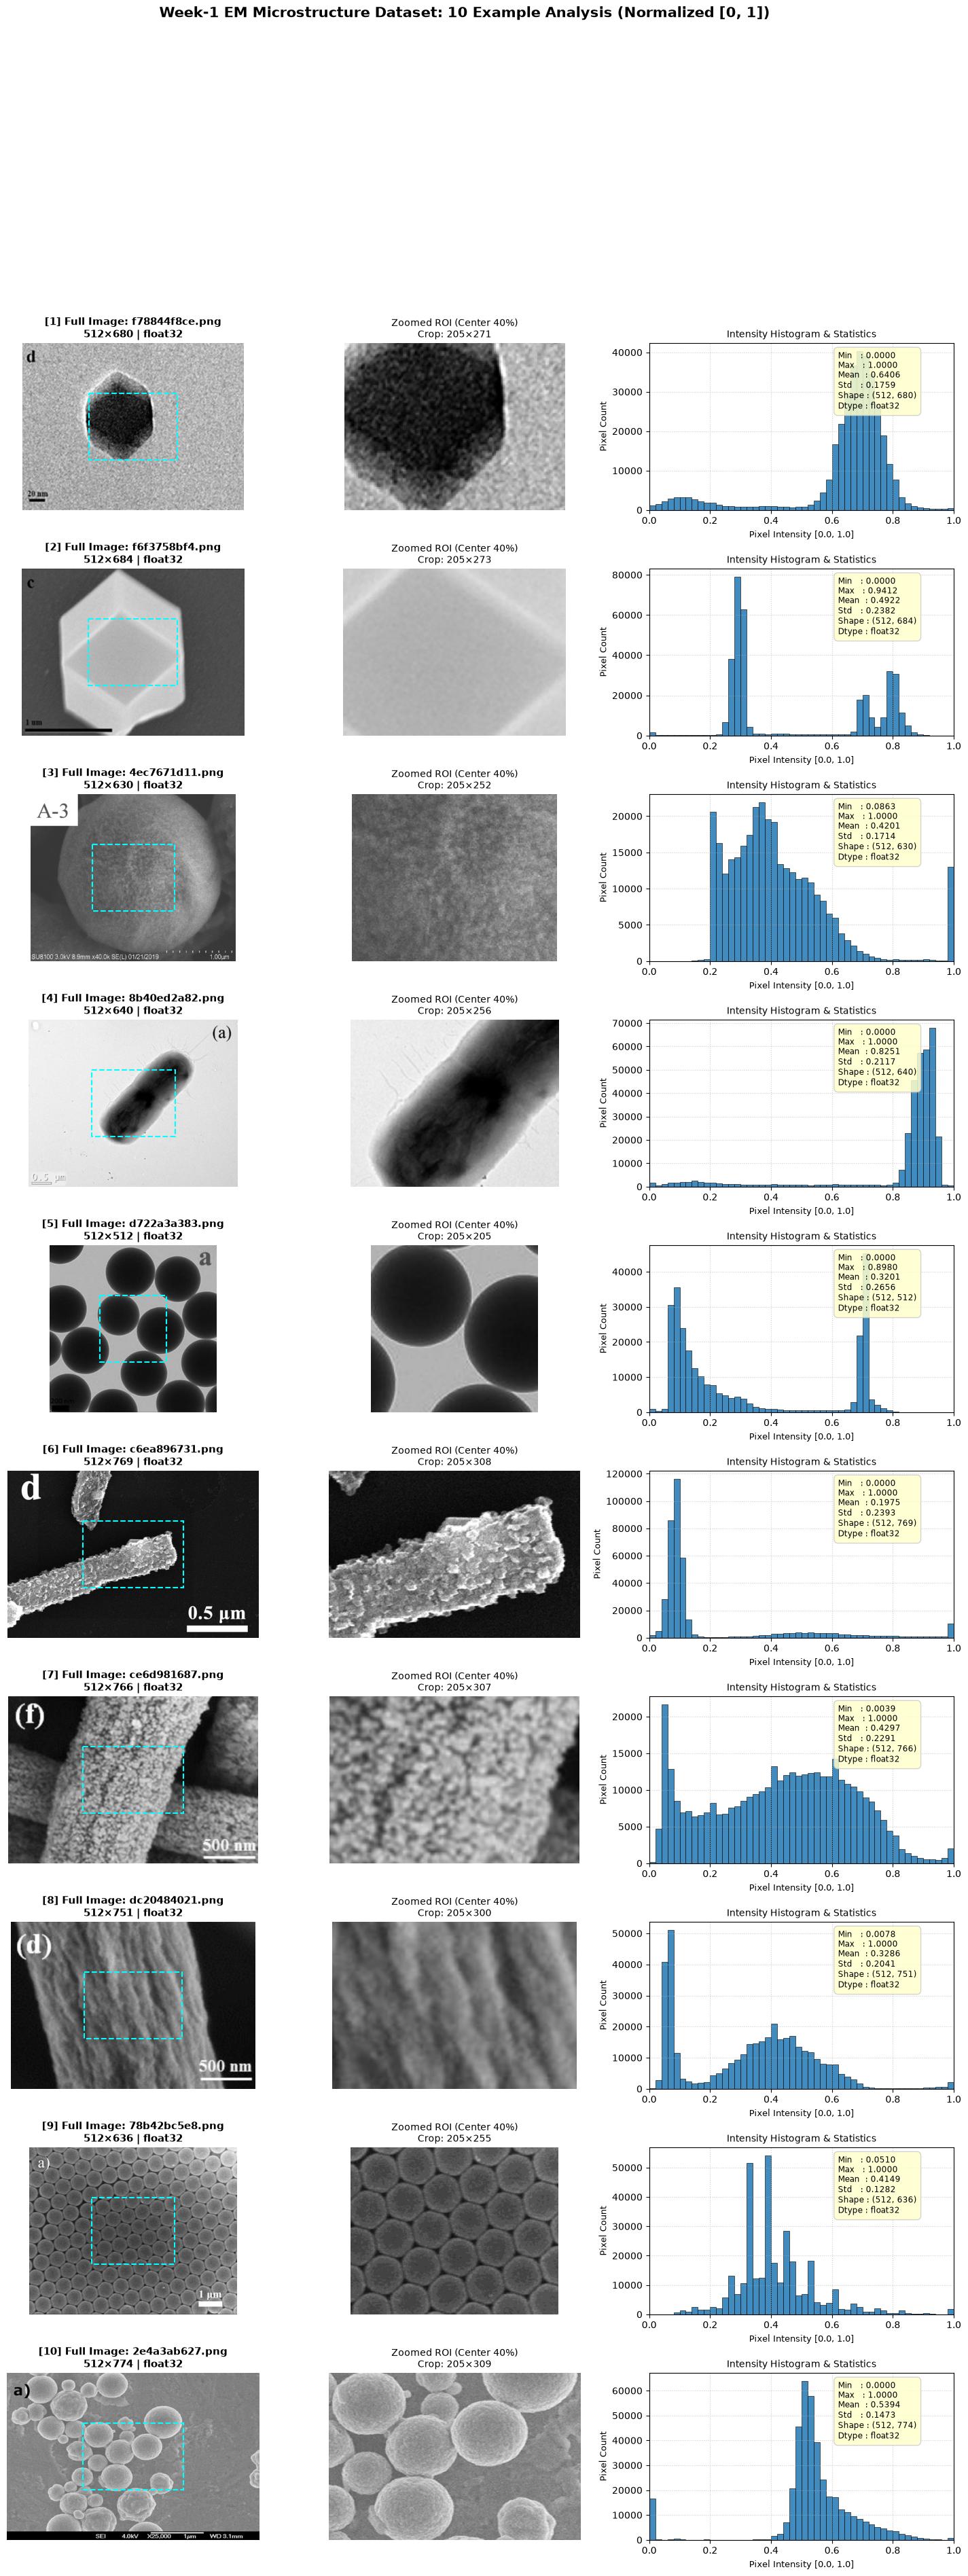

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Select 10 distinct samples from train_df
num_samples = 10
sample_ids = train_df['image_id'].iloc[:num_samples].tolist()

# Set up matplotlib style
plt.style.use('default')
fig = plt.figure(figsize=(18, 4.2 * num_samples))
gs = gridspec.GridSpec(num_samples, 3, width_ratios=[1, 1, 1.2], wspace=0.25, hspace=0.35)

sample_stats_list = []

for idx, img_id in enumerate(sample_ids):
    img, meta = load_em_image(img_id, target_norm='unit')
    sample_stats_list.append(meta)
    
    # 1. Full Image
    ax_full = fig.add_subplot(gs[idx, 0])
    im_full = ax_full.imshow(img, cmap='gray', vmin=0.0, vmax=1.0)
    ax_full.set_title(f"[{idx+1}] Full Image: {meta['filename']}\n{meta['dimensions'][0]}×{meta['dimensions'][1]} | {meta['dtype']}", fontsize=11, fontweight='bold')
    ax_full.axis('off')
    
    # 2. Zoomed Crop (Central ROI 30%-70%)
    h, w = img.shape
    crop_h_start, crop_h_end = int(h * 0.3), int(h * 0.7)
    crop_w_start, crop_w_end = int(w * 0.3), int(w * 0.7)
    crop_img = img[crop_h_start:crop_h_end, crop_w_start:crop_w_end]
    
    ax_crop = fig.add_subplot(gs[idx, 1])
    ax_crop.imshow(crop_img, cmap='gray', vmin=0.0, vmax=1.0)
    ax_crop.set_title(f"Zoomed ROI (Center 40%)\nCrop: {crop_img.shape[0]}×{crop_img.shape[1]}", fontsize=10)
    
    # Add cyan bounding box indicator on full image
    rect = plt.Rectangle((crop_w_start, crop_h_start), crop_w_end - crop_w_start, crop_h_end - crop_h_start,
                         fill=False, edgecolor='cyan', linewidth=1.5, linestyle='--')
    ax_full.add_patch(rect)
    ax_crop.axis('off')
    
    # 3. Histogram & Stats Panel
    ax_hist = fig.add_subplot(gs[idx, 2])
    counts, bins, patches = ax_hist.hist(img.ravel(), bins=50, range=(0.0, 1.0), color='#1f77b4', alpha=0.85, edgecolor='black', linewidth=0.5)
    ax_hist.set_xlim(0.0, 1.0)
    ax_hist.set_xlabel("Pixel Intensity [0.0, 1.0]", fontsize=9)
    ax_hist.set_ylabel("Pixel Count", fontsize=9)
    ax_hist.set_title(f"Intensity Histogram & Statistics", fontsize=10)
    ax_hist.grid(True, linestyle=':', alpha=0.6)
    
    # Stats Box
    stats_text = (
        f"Min   : {meta['min']:.4f}\n"
        f"Max   : {meta['max']:.4f}\n"
        f"Mean  : {meta['mean']:.4f}\n"
        f"Std   : {meta['std']:.4f}\n"
        f"Shape : {meta['dimensions']}\n"
        f"Dtype : {meta['dtype']}"
    )
    ax_hist.text(0.62, 0.95, stats_text, transform=ax_hist.transAxes, fontsize=8.5,
                 verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffffcc', alpha=0.85, edgecolor='#cccccc'))

plt.suptitle("Week-1 EM Microstructure Dataset: 10 Example Analysis (Normalized [0, 1])", fontsize=15, fontweight='bold', y=0.998)
plt.show()


## 5. Basic Image Statistics Across Samples

Aggregating microstructural image statistics for all 10 analyzed examples into a clean summary table.


In [7]:
# Create Pandas DataFrame from metadata
stats_df = pd.DataFrame(sample_stats_list)

# Compute aspect ratio
stats_df['height'] = stats_df['dimensions'].apply(lambda d: d[0])
stats_df['width'] = stats_df['dimensions'].apply(lambda d: d[1])
stats_df['aspect_ratio'] = (stats_df['width'] / stats_df['height']).round(3)

# Select key display columns
display_cols = ['filename', 'height', 'width', 'aspect_ratio', 'dtype', 'min', 'max', 'mean', 'std']
summary_table = stats_df[display_cols]

print("=" * 95)
print("EM DATASET SAMPLE IMAGE STATISTICS (NORMALIZED [0.0, 1.0])")
print("=" * 95)
print(summary_table.to_string(index=False))

# Aggregate summary statistics
print("\n" + "=" * 55)
print("AGGREGATE SAMPLE SUMMARY (MEAN ± STD ACROSS IMAGES)")
print("=" * 55)
print(f"Overall Mean Intensity : {stats_df['mean'].mean():.4f} ± {stats_df['mean'].std():.4f}")
print(f"Overall Std Dev        : {stats_df['std'].mean():.4f} ± {stats_df['std'].std():.4f}")
print(f"Min Intensity Range    : [{stats_df['min'].min():.4f}, {stats_df['min'].max():.4f}]")
print(f"Max Intensity Range    : [{stats_df['max'].min():.4f}, {stats_df['max'].max():.4f}]")


EM DATASET SAMPLE IMAGE STATISTICS (NORMALIZED [0.0, 1.0])
      filename  height  width  aspect_ratio   dtype      min      max     mean      std
f78844f8ce.png     512    680         1.328 float32 0.000000 1.000000 0.640595 0.175910
f6f3758bf4.png     512    684         1.336 float32 0.000000 0.941176 0.492220 0.238245
4ec7671d11.png     512    630         1.230 float32 0.086275 1.000000 0.420060 0.171353
8b40ed2a82.png     512    640         1.250 float32 0.000000 1.000000 0.825064 0.211703
d722a3a383.png     512    512         1.000 float32 0.000000 0.898039 0.320125 0.265575
c6ea896731.png     512    769         1.502 float32 0.000000 1.000000 0.197469 0.239335
ce6d981687.png     512    766         1.496 float32 0.003922 1.000000 0.429668 0.229088
dc20484021.png     512    751         1.467 float32 0.007843 1.000000 0.328645 0.204081
78b42bc5e8.png     512    636         1.242 float32 0.050980 1.000000 0.414872 0.128232
2e4a3ab627.png     512    774         1.512 float32 0.000000 

## 6. Domain Analysis: Noise & Degradation in Electron Microscopy (EM) vs. Ordinary Cameras

### Question:
*What makes degradation in EM images potentially different from ordinary-camera image noise?*

---

### Answer:
Unlike ordinary consumer cameras where noise arises primarily from optical light photons hitting CMOS/CCD sensors (resulting in Gaussian sensor noise, optical lens chromatic aberration, and RGB demosaicing artifacts), **Electron Microscopy (EM) image degradation stems from the quantum physics of electron-beam interactions with physical specimens and electromagnetic scanning systems**.

Key physical differences include:
1. **Poisson Shot Noise from Low Electron Dose**: To prevent electron beam radiation damage or sample heating in delicate materials, low beam currents are used, leading to signal degradation governed by Poisson distribution statistics rather than purely additive white Gaussian noise.
2. **Electrostatic Charging Artifacts**: Non-conductive or semi-conductive samples accumulate negative electrical charge under the electron beam, producing localized bright flare zones, severe edge deflection artifacts, and non-uniform contrast shifts that non-linearly distort intensity values.
3. **Raster Scan & Beam Drift Distortions**: Thermal and electromagnetic instabilities during spatial beam scanning cause non-rigid line distortion, hysteresis, and spatial blurring across scanning rows, whereas ordinary camera sensors capture entire pixel arrays simultaneously through optical lenses.
4. **Complex Scattering Contrast Dynamics**: Contrast in EM micrographs is formed by secondary electron (SE) emission or backscattered electron (BSE) angle deflection rather than surface photon reflectance, producing topography-dependent shading and depth-dependent attenuation unlike standard optical illumination.
